# Exploratory Data Analysis

## Project Overview

This notebook explores daily weather data from the California Irrigation Management Information System (CIMIS).

The goal of this project is to investigate the relationships between weather conditions and reference evapotranspiration (ETo), and to identify patterns that may be useful for developing a machine learning model to predict daily ETo.

The dataset contains five years of daily observations from five CIMIS weather stations representing different regions of California.

## Objectives

This analysis will:

- Examine the distribution of daily reference evapotranspiration.
- Explore relationships between ETo and weather variables.
- Investigate seasonal patterns in ETo.
- Compare ETo and weather patterns across stations.
- Identify unusual observations and potential outliers.
- Determine which findings may inform the machine learning modeling process.

## 1. Load and Inspect the Dataset

The cleaned dataset is loaded and its basic structure and dimensions are examined.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/CIMIS_daily_clean.csv")

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

(9051, 17)


## 2. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9051 entries, 0 to 9050
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Station Number        9051 non-null   int64         
 1   Station Name          9051 non-null   object        
 2   CIMIS Region          9051 non-null   object        
 3   Date                  9051 non-null   datetime64[ns]
 4   Jul                   9051 non-null   int64         
 5   ETo (mm)              9051 non-null   float64       
 6   Precip (mm)           9051 non-null   float64       
 7   Avg Sol Rad (W/m²)    9051 non-null   float64       
 8   Avg Vap Pres (kPa)    9051 non-null   float64       
 9   Max Air Temp (°C)     9051 non-null   float64       
 10  Min Air Temp (°C)     9051 non-null   float64       
 11  Avg Air Temp (°C)     9051 non-null   float64       
 12  Max Rel Hum (%)       9051 non-null   float64       
 13  Min Rel Hum (%)   

In [3]:
df.describe()

,Station Number,Date,Jul,ETo (mm),Precip (mm),Avg Sol Rad (W/m²),Avg Vap Pres (kPa),Max Air Temp (°C),Min Air Temp (°C),Avg Air Temp (°C),Max Rel Hum (%),Min Rel Hum (%),Avg Rel Hum (%),Dew Point (°C),Avg Wind Speed (m/s)
count,9051.000000,9051,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000,9051.000000
mean,27.139543,2024-03-01 05:08:19.966854656,183.072257,4.246018,0.801602,219.773616,1.074814,25.665529,8.778831,16.932107,81.733842,34.375649,55.134018,6.895161,1.929316
min,2.000000,2021-09-01 00:00:00,1.000000,0.000000,0.000000,3.000000,0.130000,-0.400000,-13.600000,-5.200000,26.000000,3.000000,13.000000,-19.200000,0.450000
25%,6.000000,2022-11-30 12:00:00,92.000000,2.340000,0.000000,146.000000,0.780000,19.000000,4.300000,11.500000,71.000000,20.000000,39.000000,3.400000,1.310000
50%,35.000000,2024-03-03 00:00:00,183.000000,4.090000,0.000000,223.000000,1.070000,25.100000,9.200000,16.200000,84.000000,29.000000,52.000000,7.900000,1.690000
75%,41.000000,2025-05-31 00:00:00,275.000000,6.080000,0.000000,303.000000,1.350000,32.500000,12.900000,22.250000,94.000000,47.000000,71.000000,11.500000,2.350000
max,52.000000,2026-09-02 00:00:00,366.000000,11.610000,135.800000,442.000000,2.870000,48.000000,30.600000,37.700000,100.000000,100.000000,100.000000,23.400000,8.330000
std,19.791339,NaN,105.458689,2.270205,4.731891,91.895512,0.423249,8.728002,7.024730,7.592807,14.486709,19.155793,19.327633,6.367657,0.888265


## Target Analysis

Reference evapotranspiration (ETo) is the target variable for the machine learning models. Its distribution and statistical characteristics are examined below.

In [4]:
df["ETo (mm)"].describe()

count    9051.000000
mean        4.246018
std         2.270205
min         0.000000
25%         2.340000
50%         4.090000
75%         6.080000
max        11.610000
Name: ETo (mm), dtype: float64

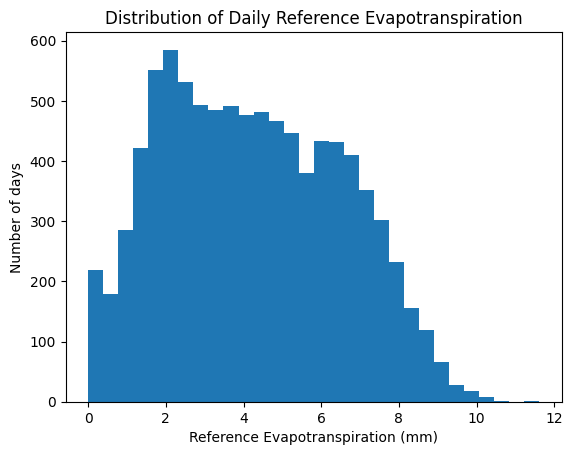

In [5]:
plt.hist(df["ETo (mm)"], bins=30)

plt.xlabel("Reference Evapotranspiration (mm)")
plt.ylabel("Number of days")
plt.title("Distribution of Daily Reference Evapotranspiration")

plt.show()

The dataset contains 9,051 observations of reference evapotranspiration (ETo). The mean ETo is 4.25 mm, while the median is 4.09 mm, indicating that the typical daily ETo value is around 4 mm. The middle 50% of observations fall between 2.34 mm and 6.08 mm.

The histogram shows that ETo values are concentrated toward the lower end of the distribution, with the two highest-frequency bins occurring around 2 mm. The distribution has a right tail toward higher ETo values, with relatively few observations above approximately 8 mm. The maximum observed ETo is 11.61 mm, but these higher values appear relatively uncommon rather than representing a large portion of the dataset.

Overall, the distribution is not symmetric and is somewhat right-skewed, which is also consistent with the mean being slightly higher than the median. The range of ETo values indicates substantial variation in daily evapotranspiration, providing the machine learning models with observations across a range of target values and environmental conditions.

## Feature Analysis

The relationship between the weather measurements and ETo are examined to identify potentially informative features.

In [6]:
correlations = df.corr(numeric_only=True)["ETo (mm)"].sort_values(ascending=False)

correlations

ETo (mm)                1.000000
Avg Sol Rad (W/m²)      0.900242
Max Air Temp (°C)       0.854784
Avg Air Temp (°C)       0.841530
Min Air Temp (°C)       0.648616
Avg Vap Pres (kPa)      0.384255
Dew Point (°C)          0.353470
Avg Wind Speed (m/s)    0.251477
Station Number         -0.002734
Jul                    -0.037382
Precip (mm)            -0.247154
Max Rel Hum (%)        -0.589724
Min Rel Hum (%)        -0.616193
Avg Rel Hum (%)        -0.691541
Name: ETo (mm), dtype: float64

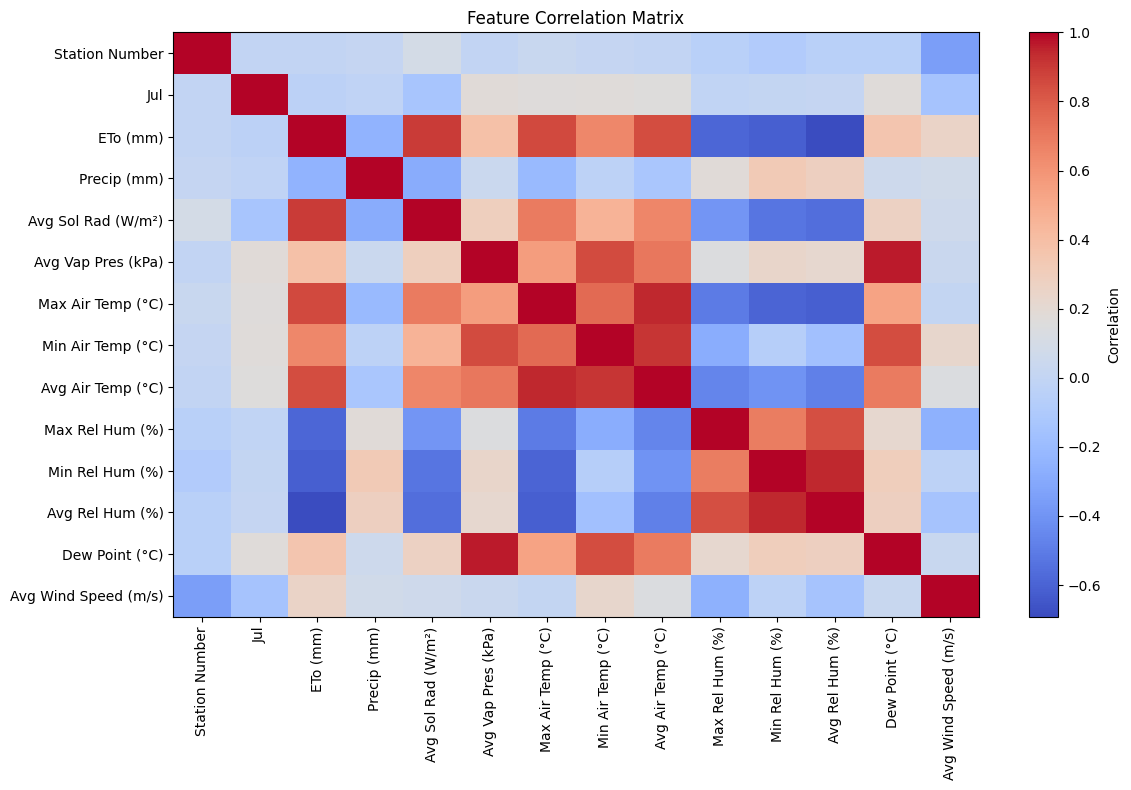

In [7]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

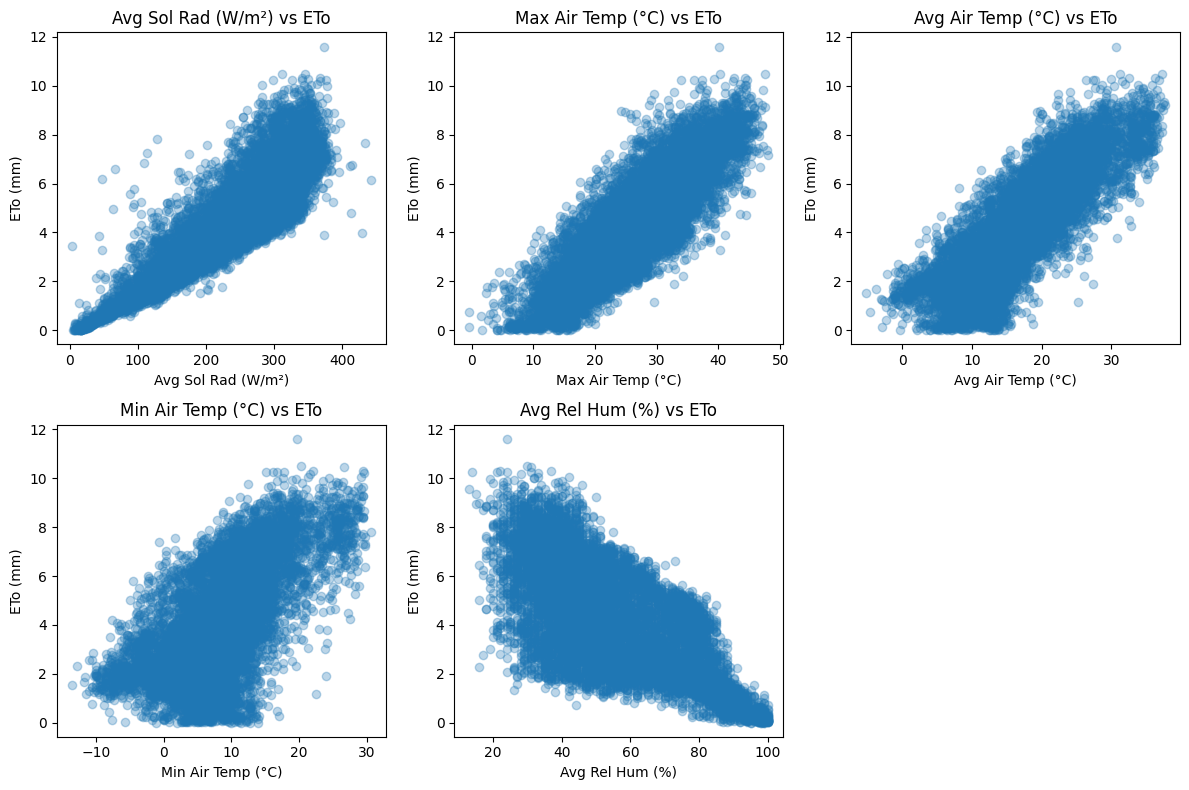

In [8]:
features = [
    "Avg Sol Rad (W/m²)",
    "Max Air Temp (°C)",
    "Avg Air Temp (°C)",
    "Min Air Temp (°C)",
    "Avg Rel Hum (%)"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):
    ax.scatter(df[feature], df["ETo (mm)"], alpha=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("ETo (mm)")
    ax.set_title(f"{feature} vs ETo")

# Hide the unused sixth subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

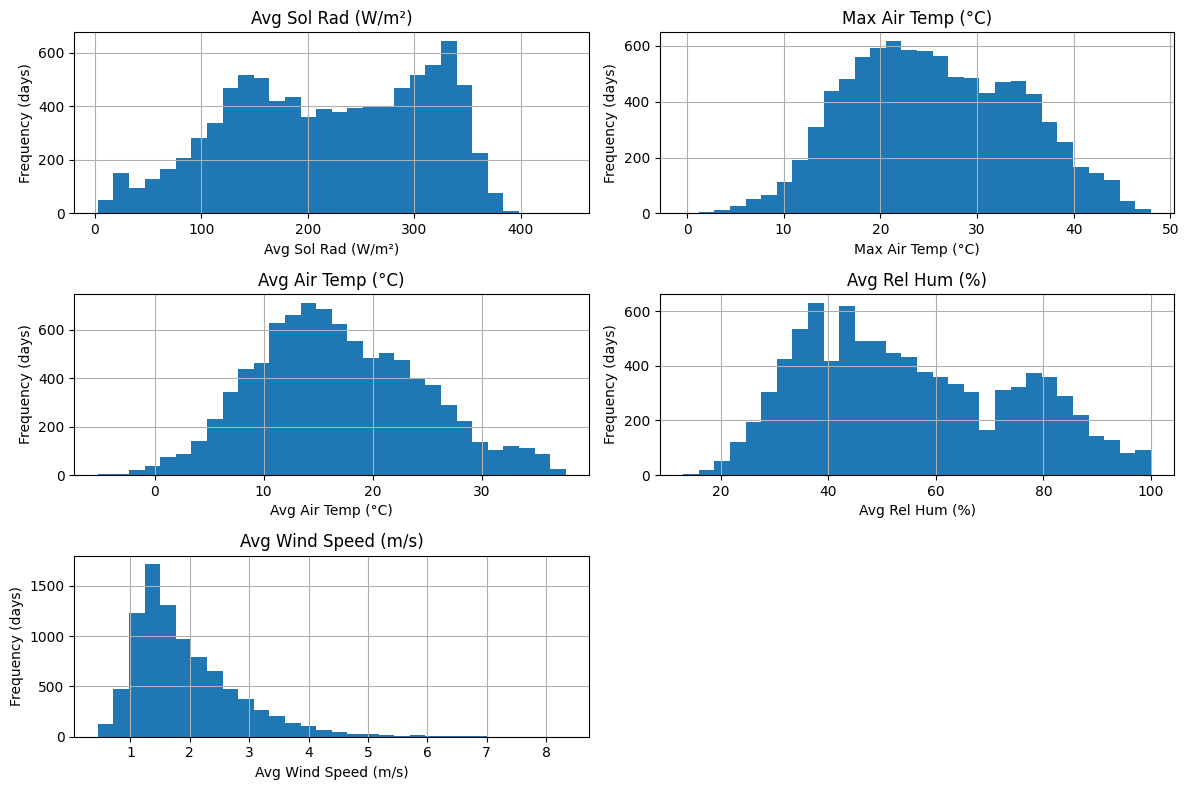

In [9]:
axes = df[
    [
        "Avg Sol Rad (W/m²)",
        "Max Air Temp (°C)",
        "Avg Air Temp (°C)",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (m/s)"
    ]
].hist(figsize=(12, 8), bins=30)

for ax, column in zip(axes.flat, [
        "Avg Sol Rad (W/m²)",
        "Max Air Temp (°C)",
        "Avg Air Temp (°C)",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (m/s)"
]):
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency (days)")
    

plt.tight_layout()
plt.show()

The correlation analysis shows that average solar radiation, maximum air temperature, and average air temperature have the strongest positive correlations with ETo. Minimum air temperature also has a relatively strong positive correlation, while average relative humidity has a strong negative correlation with ETo.

The full correlation matrix also shows that some weather features are strongly correlated with one another. For example, dew point and average vapor pressure have a strong positive correlation. This suggests that some features may contain overlapping information, which could be relevant when selecting or interpreting features in the machine learning model.

The scatter plots generally support these correlation results. Average solar radiation, maximum air temperature, average air temperature, and minimum air temperature show upward-sloping patterns, indicating that higher values of these features are generally associated with higher ETo. The relationship with minimum air temperature appears weaker than the relationships with maximum and average air temperature because some higher minimum air temperatures correspond to ETo values similar to those observed at lower minimum temperatures. Average relative humidity shows a downward-sloping pattern, indicating that higher relative humidity is generally associated with lower ETo.

The feature distributions also show several notable patterns. Average solar radiation has a bimodal distribution with a smaller peak around 150 W/m² and a larger peak around 350 W/m². Maximum air temperature has a broad, gently curved peak around 20°C, with most observations between approximately 15°C and 35°C and relatively few observations below 10°C or above 40°C. Average air temperature peaks around 15°C, with most observations between approximately 5°C and 25°C. Average relative humidity also has a bimodal distribution, with a larger peak around 40% and a smaller peak around 80%. Average wind speed is concentrated primarily between 1 and 2 m/s, followed by a sharp decline at higher wind speeds and a right tail. Overall, the distributions do not show any noticeable gaps or concentrations of extreme outliers, although a few observations are somewhat separated from the bulk of the measurements.

These findings provide a basis for selecting features for the initial machine learning models and for investigating whether features with strong relationships to one another provide overlapping information.

## Geographic Variation

In [10]:
station_means = df.groupby("Station Name")[
    [
        "ETo (mm)",
        "Avg Sol Rad (W/m²)",
        "Max Air Temp (°C)",
        "Avg Air Temp (°C)",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (m/s)"
    ]
].mean()

station_means

,ETo (mm),Avg Sol Rad (W/m²),Max Air Temp (°C),Avg Air Temp (°C),Avg Rel Hum (%),Avg Wind Speed (m/s)
Station Name,,,,,,
Bishop,4.208673,233.114671,24.586903,13.556942,41.848229,1.462676
Calipatria/Mulberry,5.401475,244.057788,31.956026,22.229169,44.683544,1.946643
Davis,3.898723,206.696753,24.023280,16.252559,63.649972,2.319108
FivePoints,4.335652,203.925439,25.641502,17.576425,55.884320,2.341206
San Luis Obispo,3.383015,211.399669,22.091566,14.969129,69.346748,1.565000


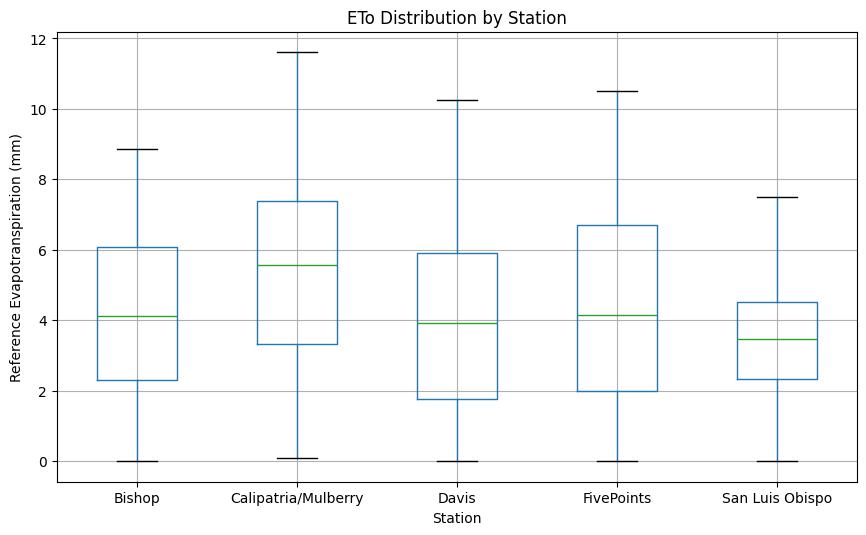

In [11]:
df.boxplot(
    column="ETo (mm)",
    by="Station Name",
    figsize=(10, 6)
)

plt.title("ETo Distribution by Station")
plt.suptitle("")
plt.xlabel("Station")
plt.ylabel("Reference Evapotranspiration (mm)")
plt.show()

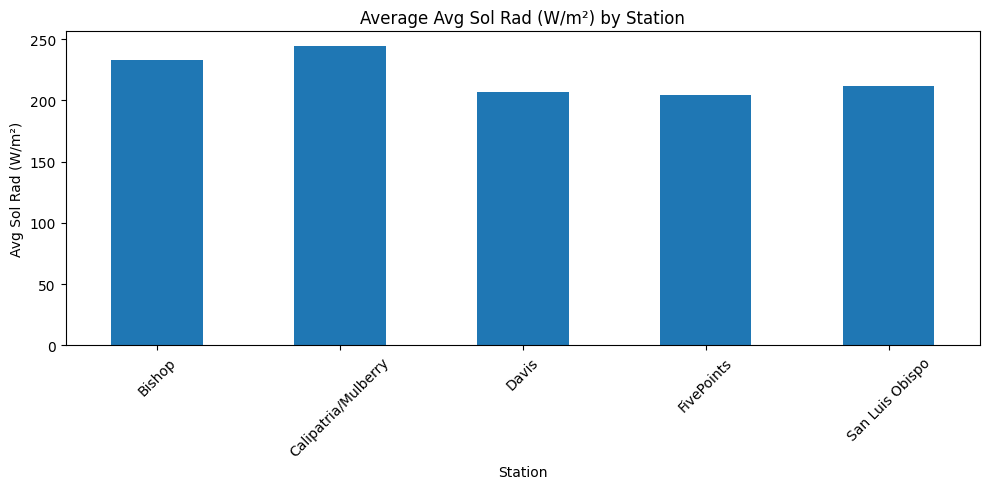

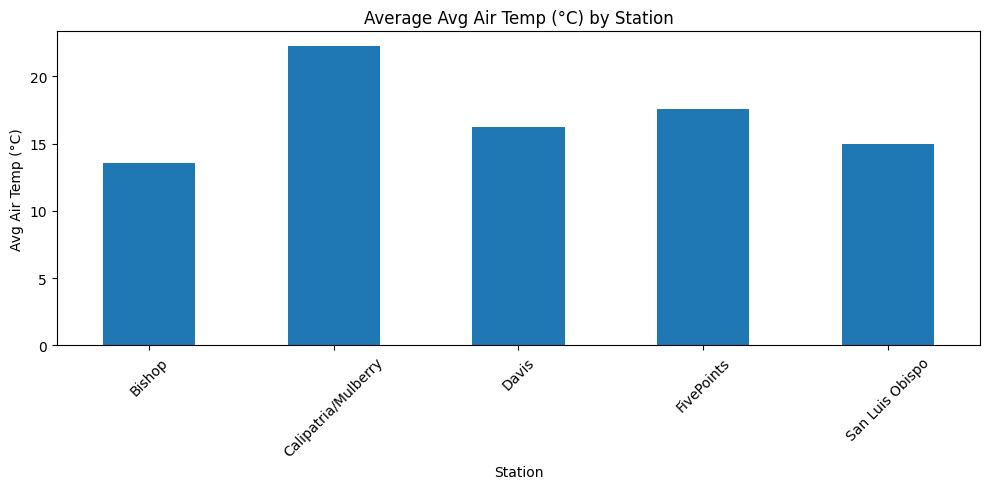

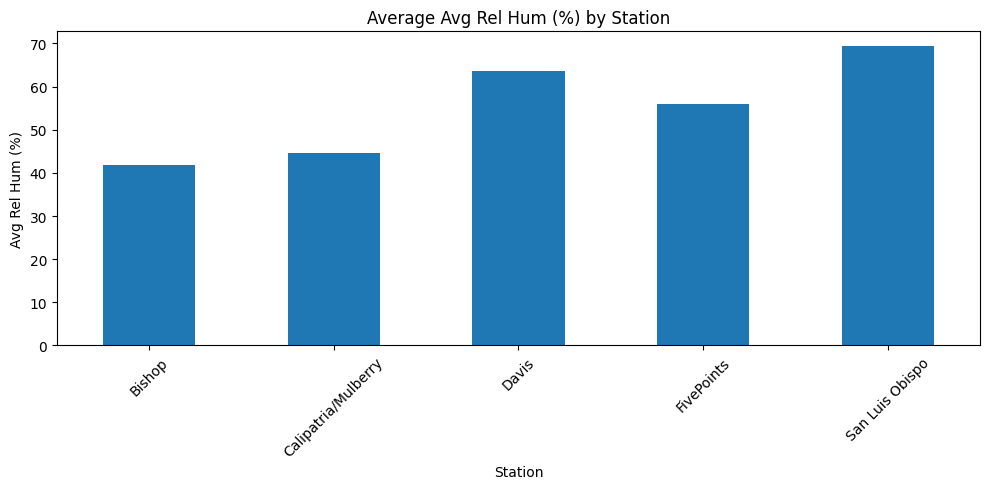

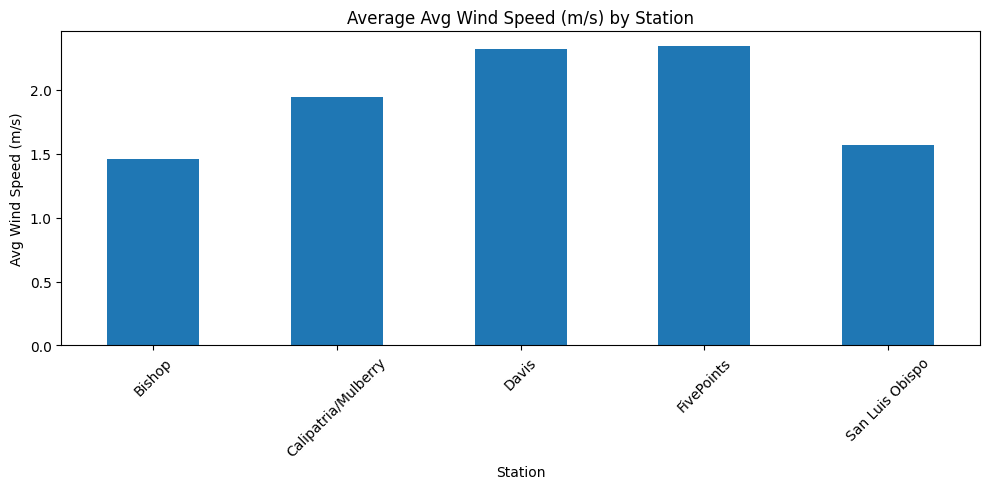

In [12]:
feature_labels = {
    "Avg Sol Rad (W/m²)": "Average Solar Radiation (W/m²)",
    "Avg Air Temp (°C)": "Average Air Temperature (°C)",
    "Avg Rel Hum (%)": "Average Relative Humidity (%)",
    "Avg Wind Speed (m/s)": "Average Wind Speed (m/s)"
}

features = list(feature_labels.keys())

for feature in features:
    station_means = df.groupby("Station Name")[feature].mean()

    plt.figure(figsize=(10, 5))
    
    station_means.plot(kind="bar")

    plt.title(f"{feature_labels[feature]} by Station")
    plt.xlabel("Station")
    plt.ylabel(feature_labels[feature])

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The station means table, ETo box plot, and weather feature comparisons all show meaningful differences in environmental conditions and ETo across the five stations. Calipatria/Mulberry has the higehest mean ETo at 5.40 mm, while San Luis Obispo has the lowest at 3.38 mm. Calipatria/Mulberry also has the highest mean average solar radiation, maximum air temperature, and average air temperature. In contrast, San Luis Obispo has the highest average relative humidity and lowest mean ETo. FivePoints has the highest average wind speed at 2.34 m/s, with Davis close behind at 2.32 m/s.

The ETo box plot provides additional information about the distribution and variability of ETo at each station. Calipatria/Mulberry has the widest overall range, extending from approximately 0 to just under 12 mm, while San Luis Obispo has the smallest range, extending from approximately 0 to just above 7 mm. FivePoints has the widest interquartile range, indicating the greatest variability within its middle 50% of observations, while San Luis Obispo has the most compact interquartile range. Calipatria/Mulberry also generally has higher ETo values, while San Luis Obispo tends to have lower values, consistent with the station mean results.

The weather feature comparisons show that average solar radiation varies somewhat between stations, with Bishop and Calipatria/Mulberry having the highest averages. Average air temperature shows a larger difference, with Calipatria/Mulberry noticeably higher than the other stations. Average relative humidity also varies substantially, with San Luis Obispo, Davis, and FivePoints having higher averages than Bishop and Calipatria/Mulberry. Average wind speed varies to a lesser extent, with Davis and FivePoints having the highest averages and San Luis Obispo and Bishop having the lowest.

Overall, the five stations represent meaningfully different environmental conditions. The higher ETo observed at Calipatria/Mulberry is consistent with its higher solar radiation and temperatures, while the lower ETo at San Luis Obispo occurs alongside higher average relative humidity. These patterns are consistent with differences in evaporative demand across the locations, although the comparisons alone do not establish causation. The geographic variation is also useful for evaluating whether a machine learning model can generalize beyond the environmental conditions represented by its training stations.

## Temporal Patterns

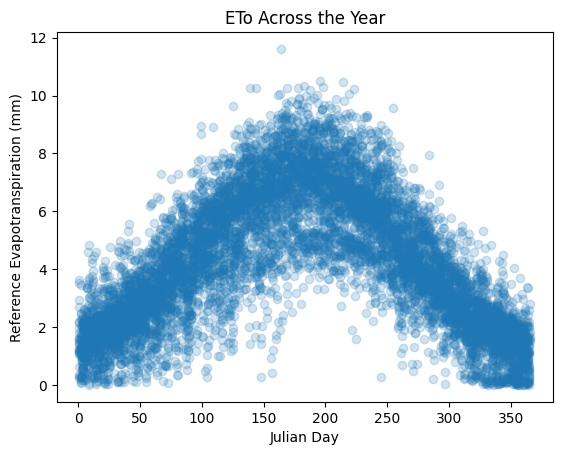

In [13]:
plt.scatter(df["Jul"], df["ETo (mm)"], alpha=0.2)

plt.xlabel("Day of Year")
plt.ylabel("Reference Evapotranspiration (mm)")
plt.title("ETo vs Day of Year")

plt.show()

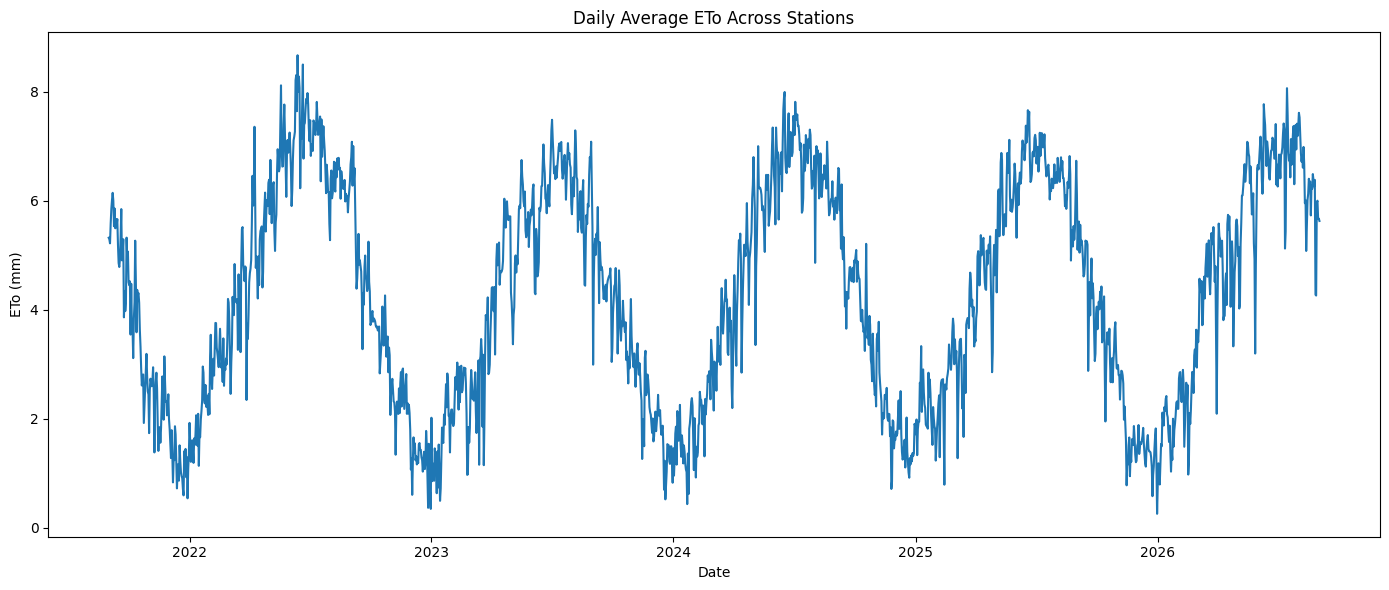

In [14]:
daily_eto = df.groupby("Date")["ETo (mm)"].mean()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_eto.index,
    daily_eto.values
)

plt.title("Daily Average ETo Across Stations")
plt.xlabel("Date")
plt.ylabel("ETo (mm)")

plt.tight_layout()
plt.show()

The ETo versus day of year scatter plot shows a clear seasonal, broad inverted U-shaped pattern. ETo values are generally lower at the beginning of the year, increase as the day of year progresses, reach their highest values between approximately days 150 and 200, and then gradually decrease toward the end of the year. Since day 1 represents January 1, this pattern corresponds to lower ETo during the winter months, increasing ETo through fall and winter. The increase and decrease occur at approximately similar rates, although the observations appear slightly more tightly clustered during the decline. This indicates that ETo has substantial seasonal variability and that the relationship between time of year is nonlinear rather than a simple linear relationship.

The daily average ETo plot across the five stations shows a distinct repeating wave pattern over the five-year period. ETo increases and decreases at approximately the same times each year, with peaks and troughs occurring in a similar seasonal pattern. The 2022-2023 period appears to have slightly higher ETo values, with a peak above 8 mm and possibly close to 9 mm, while the peaks in the other years generally fall between approximately 7 and 8 mm. However, the overall pattern and range of ETo remain similar across the five years. This consistency suggests that the seasonal pattern is persistent across years rather than being driven by a single year's conditions.

Overall, the temporal analysis shows that ETo follows a strong seasonal pattern, with values generally increasing toward the summer and decreasing toward the winter. The similar yearly patterns also suggest that time of year may provide useful information for predicting ETo, although the nonlinear relationship means that day of year may need to be represented appropriately when used as a model feature.

## EDA Conclusion

The exploratory analysis shows that daily ETo varies substantially across the dataset and is strongly associated with several weather conditions. Solar radiation and air temperature have strong positive relationships with ETo, while relative humidity has a strong negative relationship. The five weather stations also represent meaningfully different environmental conditions, resulting in differences in their typical ETo values and distributions.

ETo also follows a clear seasonal pattern, increasing through spring, reaching its highest values during the summer months, and decreasing through fall and winter. The highest ETo values are concentrated between approximately days 150 and 200, corresponding to late May through mid-July, which is consistent with the summer period at the California station locations.Although the day of year feature has little linear correlation with ETo, the scatter plot shows a clear nonlinear relationship, indicating that time of year may still provide useful information for prediction.

These findings provide a basis for selecting features and designing the initial machine learning experiments. The models can be evaluated using the weather variables identified as having strong relationships with ETo, while day of year can be investigated as a potential additional feature for capturing seasonal patterns.
